In [16]:
# ---------------------------------------------------------------
#  Re-derive correct sample names, rewrite *_LFC.tsv + summary
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# -------- EDIT THESE -------------------------------------------
LIB_ROOT   = Path("~/Downloads/sge_production_02_pyquest").expanduser()   # where *.lib_counts.tsv.gz live
LFC_OUTDIR = Path("~/Downloads/LFC_tables_fixed").expanduser()            # new/overwrite folder
CSV_OUT    = Path("~/Downloads/library_QC_plots/skew_gini_summary.csv").expanduser()
# ---------------------------------------------------------------

LFC_OUTDIR.mkdir(parents=True, exist_ok=True)

def get_sample_name(fp: Path) -> str:
    """Return directory just above 'pyquest' (targeton name) or fallback stem."""
    parts = fp.parts
    if "pyquest" in parts:
        idx = parts.index("pyquest")
        return parts[idx - 1]
    return fp.stem.split(".")[0]

def lfc_vs_uniform(counts, pseudo=1.0):
    n = len(counts)
    counts["raw_norm"] = (counts["raw"] + pseudo) / (counts["raw"].sum() + pseudo * n)
    counts["ref_norm"] = 1.0 / n
    counts["LFC"]      = np.log2(counts["raw_norm"] / counts["ref_norm"])
    return counts[["ID", "raw", "LFC"]]

summary_rows = []
for lib_fp in LIB_ROOT.rglob("*.lib_counts.tsv.gz"):
    sample = get_sample_name(lib_fp)
    # read counts
    df = pd.read_csv(lib_fp, sep="\t", comment="#",
                     names=["ID","NAME","SEQ","COUNT","UNIQUE","SAMPLE"],
                     compression="gzip")[["ID","COUNT"]].rename(columns={"COUNT":"raw"})
    lfc_df = lfc_vs_uniform(df, pseudo=1.0)
    # write LFC table
    out_tsv = LFC_OUTDIR / f"{sample}_LFC.tsv"
    lfc_df.to_csv(out_tsv, sep="\t", index=False)

    # ----- skew & gini for summary -----
    p10, p90 = np.percentile(df["raw"], [10, 90])
    skew = p90 / p10 if p10 > 0 else np.nan
    freq = df["raw"] / df["raw"].sum()
    sorted_f = np.sort(freq.values)
    lorenz = np.cumsum(sorted_f)
    gini = 1 - 2 * np.trapz(lorenz, dx=1/len(lorenz))
    summary_rows.append({"sample": sample, "skew_90/10": skew, "gini": gini})

# write updated summary CSV
pd.DataFrame(summary_rows).to_csv(CSV_OUT, index=False)
print(f"✓ {len(summary_rows)} LFC tables written to {LFC_OUTDIR}")
print(f"✓ summary CSV written to {CSV_OUT}")


✓ 637 LFC tables written to /Users/ds39/Downloads/LFC_tables_fixed
✓ summary CSV written to /Users/ds39/Downloads/library_QC_plots/skew_gini_summary.csv


In [25]:
# -----------------------------------------------------------
# Plot library 90/10 skew  +  Lorenz/Gini for every *_LFC.tsv
# -----------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# ==== EDIT PATHS =======================================================
ROOT_DIR = Path("~/Downloads/lfc_results").expanduser()   # where *_LFC.tsv live
OUT_DIR  = Path("~/Downloads/library_QC_plots").expanduser()
# =======================================================================

OUT_DIR.mkdir(parents=True, exist_ok=True)
files = list(ROOT_DIR.rglob("*_LFC.tsv"))
if not files:
    raise FileNotFoundError(f"No *_LFC.tsv found under {ROOT_DIR}")

summ = []                         # collect numbers for a CSV if you like
for fp in files:
    # ------- load counts ----------------------------------------------
    df = pd.read_csv(fp, sep="\t",
                     compression="gzip" if fp.suffix == ".gz" else None)
    counts = df["raw"].astype(float)
    sample = fp.stem.replace("_LFC", "")
    # ------- 90/10 skew -----------------------------------------------
    p10, p90 = np.percentile(counts, [10, 90])
    skew = p90 / p10
    # ------- Lorenz + Gini --------------------------------------------
    freq = counts / counts.sum()           # relative frequencies
    x = np.sort(freq.values)
    L = np.cumsum(x)                       # Lorenz y-values
    L = np.insert(L, 0, 0)                 # prepend 0 for plot
    gini = 1 - 2*np.trapz(L, dx = 1/len(x))
    # ------- figure ----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    # left panel: density + 10th/90th
    sns.kdeplot(counts, ax=ax1, fill=True)
    ax1.axvline(p10, color="red", ls="--", lw=1)
    ax1.axvline(p90, color="red", ls="--", lw=1)
    ax1.set_xlabel("Raw read count")
    ax1.set_ylabel("Density")
    ax1.set_title(f"{sample}: skew (90/10) = {skew:.2f}")
    # right panel: Lorenz + Gini
    ax2.plot(np.linspace(0, 1, len(L)), L, lw=2)
    ax2.plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
    ax2.set_xlabel("Cumulative share of oligos")
    ax2.set_ylabel("Cumulative share of reads")
    ax2.set_title(f"Lorenz curve (Gini = {gini:.2f})")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{sample}_skew_gini.png", dpi=300)
    plt.close(fig)
    # record summary numbers
    summ.append({"sample": sample, "skew_90/10": skew, "gini": gini})

# ------- optional CSV summary -----------------------------------------
pd.DataFrame(summ).to_csv(OUT_DIR / "skew_gini_summary.csv", index=False)
print(f"✓ {len(summ)} samples done — figures saved in {OUT_DIR}")


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  skew = p90 / p10
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:26: RuntimeWarning: invalid value encountered in scalar divide
  skew = p90 / p10
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(counts, ax=ax1, fill=True)
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:26: RuntimeWarning: invalid value encountered in scalar divide
  skew = p90 / p10
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:26: RuntimeWarning: invalid value encountered in scalar divide
  skew = p90 / p10
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/1293075447.py:26: RuntimeWarning: divide by zero e

✓ 455 samples done — figures saved in /Users/ds39/Downloads/library_QC_plots


In [26]:
# ---------------------------------------------------------------
#  Robust Skew vs Gini plot  (good / medium / bad)
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Rectangle

CSV = Path("~/Downloads/library_QC_plots/skew_gini_summary_filtered.csv").expanduser()
OUT = CSV.parent / "skew_vs_gini_final.png"

df = pd.read_csv(CSV)

# --- replace inf with NaN, then drop any NaNs -------------------
df["skew_90/10"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["gini"].replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["skew_90/10", "gini"])

if df.empty:
    raise SystemExit("Nothing to plot after removing NaN/Inf values.")

# thresholds
GOOD_SKEW, BAD_SKEW = 4, 8
GOOD_GINI, BAD_GINI = 0.20, 0.35

# finite axis limits with fall-backs
x_max = float(df["skew_90/10"].max()) * 1.1
y_max = float(df["gini"].max()) * 1.05
if not np.isfinite(x_max) or x_max <= 1:
    x_max = 10
if not np.isfinite(y_max) or y_max <= 0:
    y_max = 1

fig, ax = plt.subplots(figsize=(6.5, 5))

# ---------------- background zones ------------------------------
ax.add_patch(Rectangle((1, 0),                GOOD_SKEW-1, GOOD_GINI,
                       fc="#d4ecd4"))  # green
ax.add_patch(Rectangle((1, GOOD_GINI),        GOOD_SKEW-1, BAD_GINI-GOOD_GINI,
                       fc="#fff5cc"))  # yellow (upper-left)
ax.add_patch(Rectangle((GOOD_SKEW, 0),        BAD_SKEW-GOOD_SKEW, GOOD_GINI,
                       fc="#fff5cc"))  # yellow (lower-middle)
ax.add_patch(Rectangle((1, BAD_GINI),         x_max-1, y_max-BAD_GINI,
                       fc="#f7d6d6", alpha=.9))  # red top band
ax.add_patch(Rectangle((BAD_SKEW, 0),         x_max-BAD_SKEW, BAD_GINI,
                       fc="#f7d6d6", alpha=.9))  # red right band

# guideline dashed lines
for x in (GOOD_SKEW, BAD_SKEW):
    ax.axvline(x, ls=":", c="grey", lw=1)
for y in (GOOD_GINI, BAD_GINI):
    ax.axhline(y, ls=":", c="grey", lw=1)

# scatter points
ax.scatter(df["skew_90/10"], df["gini"],
           s=20, alpha=0.5, ec="none", fc="steelblue")

# axes
ax.set_xscale("log", base=10)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64])
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.set_xlim(1, x_max)
ax.set_ylim(0, y_max)

ax.set_xlabel("Distribution skew  (90th ÷ 10th percentile, log scale)")
ax.set_ylabel("Gini coefficient")
ax.set_title("Plasmid-library uniformity across targetons")

# legend
handles = [
    Rectangle((0,0),1,1,fc="#d4ecd4", label="good"),
    Rectangle((0,0),1,1,fc="#fff5cc", label="medium"),
    Rectangle((0,0),1,1,fc="#f7d6d6", label="bad")
]
ax.legend(handles=handles, loc="upper left", frameon=False)

fig.tight_layout()
fig.savefig(OUT, dpi=300)
plt.close(fig)

print(f"✓ final plot saved → {OUT}")






/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/3311971692.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["skew_90/10"].replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/3311971692.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

✓ final plot saved → /Users/ds39/Downloads/library_QC_plots/skew_vs_gini_final.png


In [17]:
# ------------------------------------------------------------------
#  Sort skew_gini_summary.csv from good → medium → bad
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd

CSV_IN  = Path("~/Downloads/library_QC_plots/skew_gini_summary.csv").expanduser()
CSV_OUT = CSV_IN.parent / "skew_gini_summary_sorted.csv"

df = pd.read_csv(CSV_IN)

# --- define cut-offs (same as the figure) --------------------------
GOOD_GINI, BAD_GINI = 0.20, 0.35
SKEW_WARN           = 8

def classify(row):
    if row["gini"] <= GOOD_GINI and row["skew_90/10"] <= SKEW_WARN:
        return "good"
    elif row["gini"] <= BAD_GINI and row["skew_90/10"] <= SKEW_WARN:
        return "medium"
    else:
        return "bad"

df["quality"] = df.apply(classify, axis=1)

# --- sort: first by quality (good→medium→bad), then by Gini --------
q_order = {"good": 0, "medium": 1, "bad": 2}
df_sorted = (df
             .assign(q_rank=df["quality"].map(q_order))
             .sort_values(["q_rank", "gini", "skew_90/10"])
             .drop(columns="q_rank"))

df_sorted.to_csv(CSV_OUT, index=False)
print(f"✓ sorted table written → {CSV_OUT}")


✓ sorted table written → /Users/ds39/Downloads/library_QC_plots/skew_gini_summary_sorted.csv


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_49307/189741896.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = (df.groupby("quality")["Average_mapped_reads"]


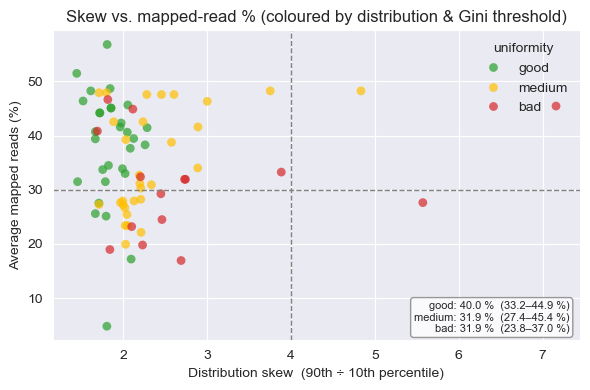

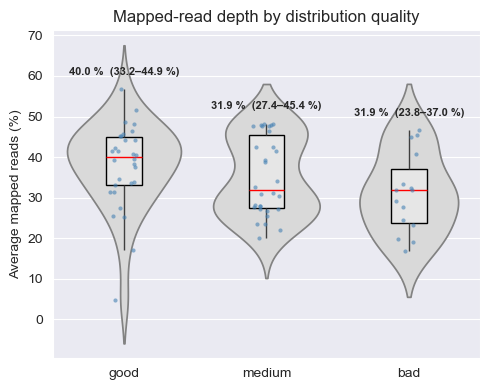

✓ scatter saved → /Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/library_QC_plots/skew_vs_depth_quality_scatter.png
✓ violin / box saved → /Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/library_QC_plots/mapped_reads_by_quality_violin.png


In [42]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
#  File locations
# ------------------------------------------------------------------
CSV = Path("/Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/"
           "library_QC_plots/skew_gini_summary_filtered.csv")

OUT_DIR = CSV.parent
SCATTER_PNG = OUT_DIR / "skew_vs_depth_quality_scatter.png"
VIOLIN_PNG  = OUT_DIR / "mapped_reads_by_quality_violin.png"

# ------------------------------------------------------------------
#  Load + clean
# ------------------------------------------------------------------
df = (pd.read_csv(CSV)
        .dropna(subset=["Average_mapped_reads"]))       # keep rows with depth

# convert to % if needed
# df["Average_mapped_reads"] *= 100

qual_order = ["good", "medium", "bad"]
df["quality"] = pd.Categorical(df["quality"], categories=qual_order, ordered=True)

palette = {"good": "#2ca02c", "medium": "#ffbf00", "bad": "#d62728"}

# ------------------------------------------------------------------
#  Compute median & IQR strings
# ------------------------------------------------------------------
stats = (df.groupby("quality")["Average_mapped_reads"]
           .describe(percentiles=[.25, .5, .75])
           .rename(columns={"25%":"q25","50%":"median","75%":"q75"}))
stats["label"] = (stats["median"].round(1).astype(str) + " %  ("
                  + stats["q25"].round(1).astype(str) + "–"
                  + stats["q75"].round(1).astype(str) + " %)")

# ------------------------------------------------------------------
#  1) SCATTER
# ------------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x="skew_90/10", y="Average_mapped_reads",
                hue="quality", palette=palette,
                data=df, s=40, alpha=.7, edgecolor="none")

# guideline lines
plt.axhline(30, ls="--", c="grey", lw=1)
plt.axvline(4,  ls="--", c="grey", lw=1)

plt.xlabel("Distribution skew  (90th ÷ 10th percentile)")
plt.ylabel("Average mapped reads (%)")
plt.title("Skew vs. mapped-read % (coloured by distribution & Gini threshold)")


# place legend top-right
plt.legend(title="uniformity", frameon=False, loc="upper right")

# summary block bottom-right
labels = "\n".join(f"{q}: {stats.loc[q,'label']}" for q in qual_order)
plt.text(0.98, 0.02, labels,
         transform=plt.gca().transAxes, ha="right", va="bottom",
         fontsize=8, bbox=dict(boxstyle="round,pad=0.3",
                               fc="white", ec="grey", alpha=0.8))

plt.tight_layout()
plt.savefig(SCATTER_PNG, dpi=300)
plt.show()

# ------------------------------------------------------------------
#  2) VIOLIN + BOX + STRIP
# ------------------------------------------------------------------
plt.figure(figsize=(5,4))
sns.violinplot(x="quality", y="Average_mapped_reads",
               data=df, order=qual_order,
               inner=None, color="#d9d9d9")                     # light grey violin
sns.boxplot(x="quality", y="Average_mapped_reads",
            data=df, order=qual_order, width=.25,
            showcaps=False, fliersize=0,
            boxprops=dict(facecolor="#e6e6e6", edgecolor="black"),
            medianprops=dict(color="red"))
sns.stripplot(x="quality", y="Average_mapped_reads",
              data=df, order=qual_order,
              color="steelblue", size=3, alpha=.6)

# label above each violin tip  (use max value + small padding)
padding = 3
for i, q in enumerate(qual_order):
    y_pos = df.loc[df["quality"] == q, "Average_mapped_reads"].max() + padding
    plt.text(i, y_pos, stats.loc[q, "label"],
             ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.ylabel("Average mapped reads (%)")
plt.xlabel("")
plt.title("Mapped-read depth by distribution quality")
plt.tight_layout()
plt.savefig(VIOLIN_PNG, dpi=300)
plt.show()

print(f"✓ scatter saved → {SCATTER_PNG}")
print(f"✓ violin / box saved → {VIOLIN_PNG}")





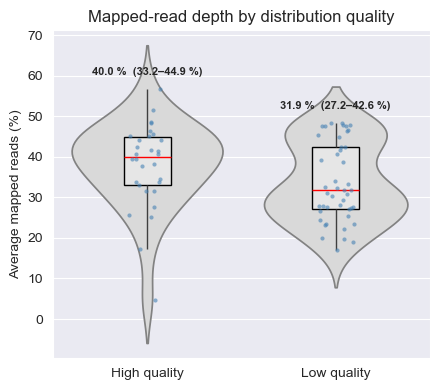

                 median        q25        q75
qual2                                        
High quality  40.050000  33.183333  44.875000
Low quality   31.933333  27.233333  42.566667
✓ figure saved → /Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/library_QC_plots/mapped_reads_good_vs_nongood_violin.png


In [47]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------
CSV = Path("/Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/"
           "library_QC_plots/skew_gini_summary_filtered.csv")
OUT_PNG = CSV.parent / "mapped_reads_good_vs_nongood_violin.png"
# ---------------------------------------------------------------

df = (pd.read_csv(CSV)
        .dropna(subset=["Average_mapped_reads"]))

# If depth is a fraction 0–1, convert to %
# df["Average_mapped_reads"] *= 100

# ----------------------------------------------------------------
# Collapse medium + bad → non-good
df["qual2"] = df["quality"].replace({"good": "High quality", "medium": "Low quality", "bad": "Low quality"})
qual_order = ["High quality", "Low quality"]

# Stats for labels
stats = (df.groupby("qual2")["Average_mapped_reads"]
           .describe(percentiles=[.25,.5,.75])
           .rename(columns={"25%":"q25","50%":"median","75%":"q75"}))
stats["label"] = (stats["median"].round(1).astype(str) + " %  ("
                  + stats["q25"].round(1).astype(str) + "–"
                  + stats["q75"].round(1).astype(str) + " %)")

# ----------------------------------------------------------------
plt.figure(figsize=(4.5,4))
sns.violinplot(x="qual2", y="Average_mapped_reads",
               data=df, order=qual_order,
               inner=None, color="#d9d9d9")
sns.boxplot(x="qual2", y="Average_mapped_reads",
            data=df, order=qual_order, width=.25,
            showcaps=False, fliersize=0,
            boxprops=dict(facecolor="#e6e6e6", edgecolor="black"),
            medianprops=dict(color="red"))
sns.stripplot(x="qual2", y="Average_mapped_reads",
              data=df, order=qual_order,
              color="steelblue", size=3, alpha=.6)

# annotate above each violin
pad = 3
for i, q in enumerate(qual_order):
    y = df.loc[df["qual2"]==q, "Average_mapped_reads"].max() + pad
    plt.text(i, y, stats.loc[q,"label"],
             ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.ylabel("Average mapped reads (%)")
plt.xlabel("")
plt.title("Mapped-read depth by distribution quality")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.show()

print(stats[["median","q25","q75"]])
print(f"✓ figure saved → {OUT_PNG}")


In [4]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FixedLocator
from matplotlib.patches import Rectangle

CSV = Path("~/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/library_QC_plots/skew_gini_summary_filtered.csv").expanduser()
OUT = CSV.parent / "skew_vs_gini_filtered.png"

df = pd.read_csv(CSV)

# --- filter out samples without mapping reads -------------------
if "Average_mapped_reads" not in df.columns:
    raise ValueError("Expected a column named 'Average_mapped_reads'.")

df = df[df["Average_mapped_reads"].fillna(0) > 0]

# --- clean up NaNs and infs -------------------------------------
df["skew_90/10"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["gini"].replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["skew_90/10", "gini"])

if df.empty:
    raise SystemExit("Nothing to plot after filtering for mapping reads and removing NaN/Inf values.")

# thresholds
GOOD_SKEW, BAD_SKEW = 4, 8
GOOD_GINI, BAD_GINI = 0.20, 0.35

# fallback axis limits
x_max = 10
y_max = 0.9

fig, ax = plt.subplots(figsize=(6.5, 5))

# ---------------- background zones ------------------------------
ax.add_patch(Rectangle((1, 0),                GOOD_SKEW-1, GOOD_GINI, fc="#d4ecd4"))  # green
ax.add_patch(Rectangle((1, GOOD_GINI),        GOOD_SKEW-1, BAD_GINI-GOOD_GINI, fc="#fff5cc"))  # yellow (upper-left)
ax.add_patch(Rectangle((GOOD_SKEW, 0),        BAD_SKEW-GOOD_SKEW, GOOD_GINI, fc="#fff5cc"))  # yellow (lower-middle)
ax.add_patch(Rectangle((1, BAD_GINI),         x_max-1, y_max-BAD_GINI, fc="#f7d6d6", alpha=.9))  # red top
ax.add_patch(Rectangle((BAD_SKEW, 0),         x_max-BAD_SKEW, BAD_GINI, fc="#f7d6d6", alpha=.9))  # red right

# guideline dashed lines
for x in (GOOD_SKEW, BAD_SKEW):
    ax.axvline(x, ls=":", c="grey", lw=1)
for y in (GOOD_GINI, BAD_GINI):
    ax.axhline(y, ls=":", c="grey", lw=1)

# scatter points
ax.scatter(df["skew_90/10"], df["gini"], s=20, alpha=0.5, ec="none", fc="steelblue")

# axis configuration
ax.set_xscale("log", base=10)
ax.set_xlim(1, x_max)
ax.set_xticks([1, 2, 4, 8])
ax.get_xaxis().set_major_formatter(ScalarFormatter())

ax.set_ylim(0, y_max)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])

ax.set_xlabel("Distribution skew  (90th ÷ 10th percentile, log scale)")
ax.set_ylabel("Gini coefficient")
ax.set_title("Plasmid-library uniformity across targetons")

# legend
handles = [
    Rectangle((0,0),1,1,fc="#d4ecd4", label="good"),
    Rectangle((0,0),1,1,fc="#fff5cc", label="medium"),
    Rectangle((0,0),1,1,fc="#f7d6d6", label="bad")
]
ax.legend(handles=handles, loc="upper left", frameon=False)

fig.tight_layout()
fig.savefig(OUT, dpi=300)
plt.close(fig)

print(f"✓ final plot saved → {OUT}")



/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_59327/3319022265.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["skew_90/10"].replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_59327/3319022265.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

✓ final plot saved → /Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/250501_allPlasmidsQC/library_QC_plots/skew_vs_gini_filtered.png
